# Exploratory Data Analisys

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Primera vista de datos

Carga

In [2]:
ROUTE_DATA = rf"../data/raw/Churn_Modelling.csv"

In [3]:
df = pd.read_csv(ROUTE_DATA)

Head

In [4]:
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

Describe

In [5]:
print(df.describe())

         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min         0.000000     

Cantidad de nulos por columna

In [6]:
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Columnas que son str

In [7]:
for col in df.columns:
    if df[col].dtype == "str":
        print(df[col])

0        Hargrave
1            Hill
2            Onio
3            Boni
4        Mitchell
          ...    
9995     Obijiaku
9996    Johnstone
9997          Liu
9998    Sabbatini
9999       Walker
Name: Surname, Length: 10000, dtype: str
0        France
1         Spain
2        France
3        France
4         Spain
         ...   
9995     France
9996     France
9997     France
9998    Germany
9999     France
Name: Geography, Length: 10000, dtype: str
0       Female
1       Female
2       Female
3       Female
4       Female
         ...  
9995      Male
9996      Male
9997    Female
9998      Male
9999    Female
Name: Gender, Length: 10000, dtype: str


## Comprensión de datos mediante gráficas

#### Cantidad que se van vs los que se quedan

In [8]:
exited_count = df["Exited"].value_counts()

In [9]:
print(exited_count)

Exited
0    7963
1    2037
Name: count, dtype: int64


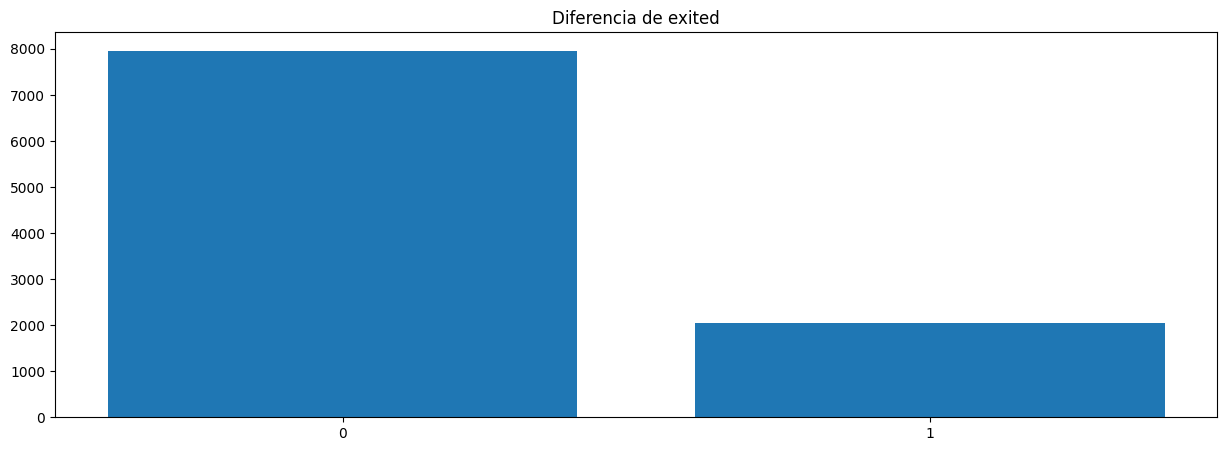

In [10]:
plt.figure(figsize=(15, 5))
plt.title("Diferencia de exited")
plt.xticks([0, 1])

plt.bar(
    exited_count.index,
    exited_count.values
)

plt.savefig("../outputs/figures/exited_count.png", bbox_inches="tight")

#### Distribución por CreditScore

<Axes: xlabel='Exited', ylabel='CreditScore'>

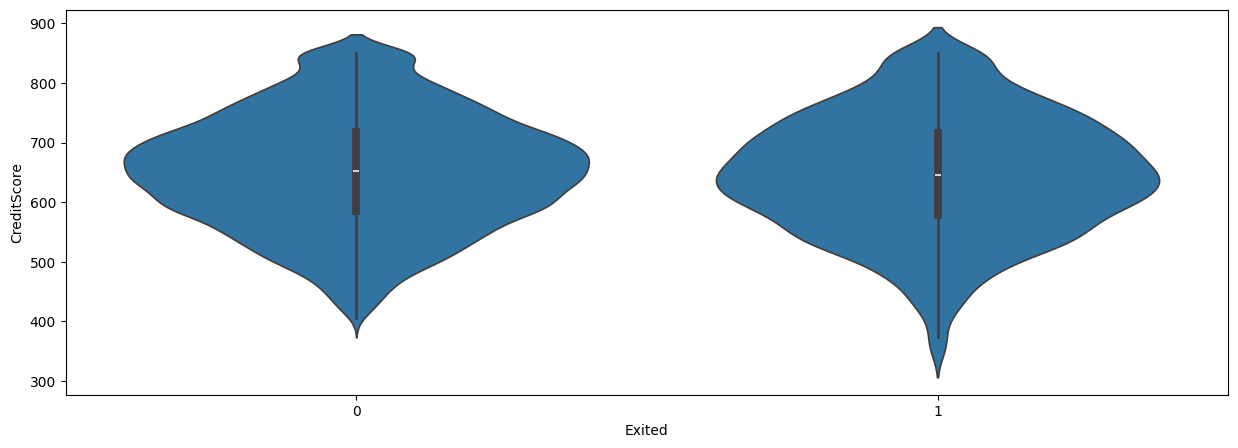

In [11]:
plt.figure(figsize=(15, 5))

sns.violinplot(
    df,
    x="Exited",
    y="CreditScore"
)

#### Exited por país

In [12]:
exited_x_geography = df.groupby("Geography")["Exited"].value_counts()

In [13]:
print(exited_x_geography)

Geography  Exited
France     0         4204
           1          810
Germany    0         1695
           1          814
Spain      0         2064
           1          413
Name: count, dtype: int64


In [14]:
exited_x_geography = exited_x_geography.unstack()

In [15]:
print(exited_x_geography)

Exited        0    1
Geography           
France     4204  810
Germany    1695  814
Spain      2064  413


<Figure size 1500x500 with 0 Axes>

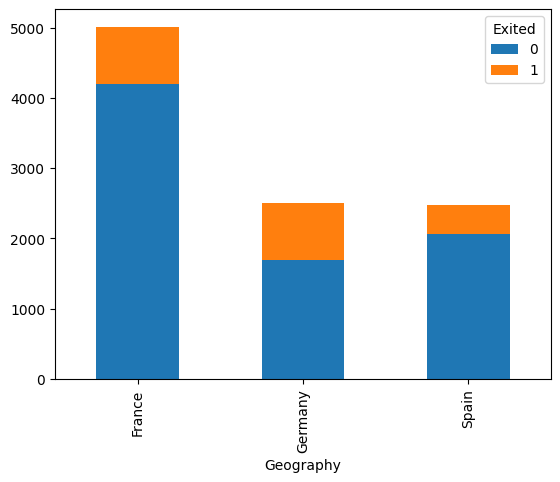

In [16]:
plt.figure(figsize=(15, 5))


exited_x_geography.plot(
    kind="bar",
    stacked=True
)

plt.savefig("../outputs/figures/exited_by_geography_count.png", bbox_inches="tight")


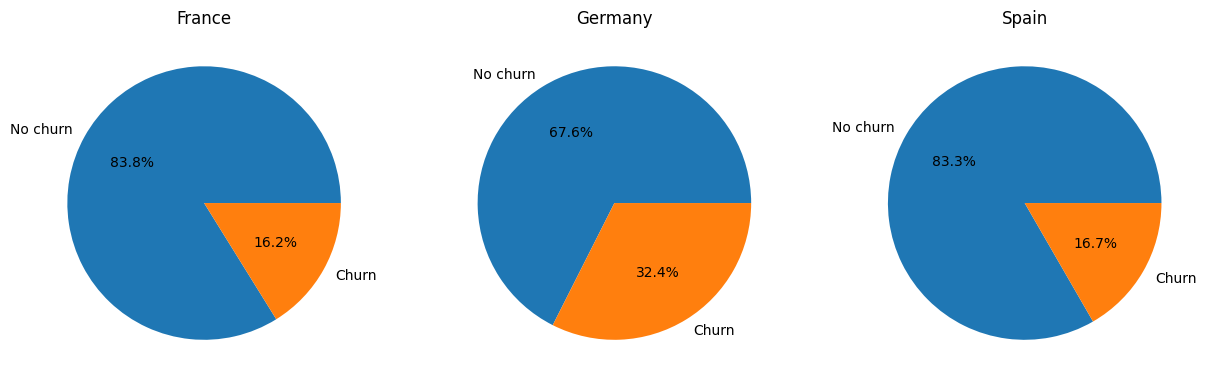

In [17]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(15, 5))

axs1 = axs[0]
axs2 = axs[1]
axs3 = axs[2]

axs1.pie(
    exited_x_geography.loc["France"],
    labels=["No churn", "Churn"],
    autopct="%1.1f%%"
)
axs1.set_title("France")

axs2.pie(
    exited_x_geography.loc["Germany"],
    labels=["No churn", "Churn"],
    autopct="%1.1f%%"
)
axs2.set_title("Germany")

axs3.pie(
    exited_x_geography.loc["Spain"],
    labels=["No churn", "Churn"],
    autopct="%1.1f%%"
)
axs3.set_title("Spain")

plt.savefig("../outputs/figures/exited_by_geography_pies.png", bbox_inches="tight")

#### Distribución de edades

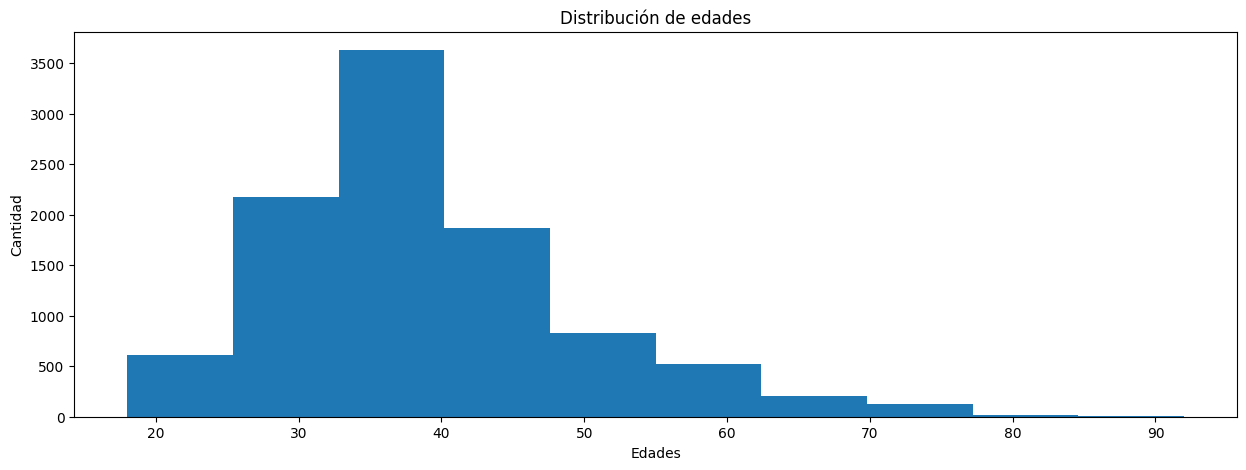

In [18]:
plt.figure(figsize=(15, 5))
plt.hist(
    df["Age"]
)

plt.title("Distribución de edades")
plt.xlabel("Edades")
plt.ylabel("Cantidad")

plt.savefig("../outputs/figures/age_distribution.png", bbox_inches="tight")

#### Churn por grupo etario

Esto lo que hace es crear otra serie, la cual hace cortes, por edad, de 18 a 30, 30 a 45, etc. Y les pone lo que salga en labels en ese orden. Además right=False es para que no considera el de la derecha dentro del grupo, considera ej: 18 <= X < 30

In [19]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[
        18, 
        30, 
        45, 
        60, 
        93
    ],
    labels=[
        "Young adult",
        "Adult",
        "Middle Age",
        "Senior"
    ],
    right="False"
)

In [20]:
df_young_adult = df[df["AgeGroup"] == "Young adult"]
df_adult = df[df["AgeGroup"] == "Adult"]
df_middle_age = df[df["AgeGroup"] == "Middle Age"]
df_senior = df[df["AgeGroup"] == "Senior"]

In [22]:
print(df_young_adult["Exited"].value_counts())

Exited
0    1800
1     146
Name: count, dtype: int64


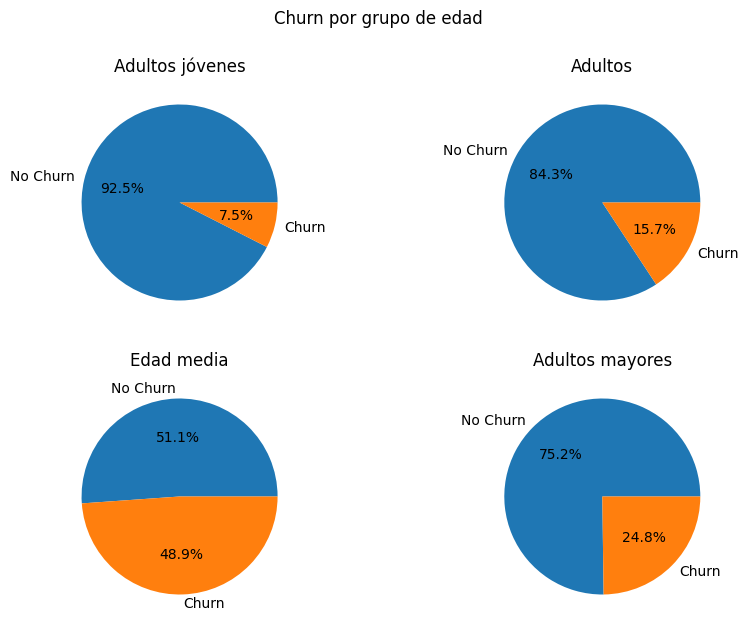

In [23]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 7))

fig.suptitle("Churn por grupo de edad")

axs1 = axs[0][0]
axs2 = axs[0][1]
axs3 = axs[1][0]
axs4 = axs[1][1]

axs1.pie(
    df_young_adult["Exited"].value_counts(),
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)
axs1.set_title("Adultos jóvenes")
#----------------------
axs2.pie(
    df_adult["Exited"].value_counts(),
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)
axs2.set_title("Adultos")
#----------------------
axs3.pie(
    df_middle_age["Exited"].value_counts(),
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)
axs3.set_title("Edad media")
#----------------------
axs4.pie(
    df_senior["Exited"].value_counts(),
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)
axs4.set_title("Adultos mayores")
plt.savefig("../outputs/figures/churn_by_ageGroup.png", bbox_inches="tight")

#### Distribución de churn por tenure

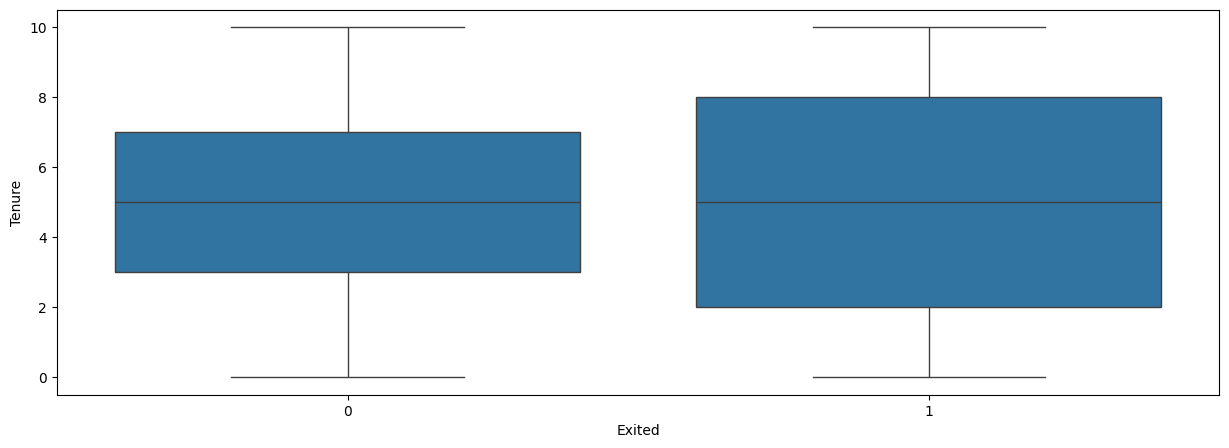

In [24]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df,
    x="Exited",
    y="Tenure"
)

plt.savefig("../outputs/figures/tenure_distribution_by_exited.png", bbox_inches="tight")

#### Distribución del balance

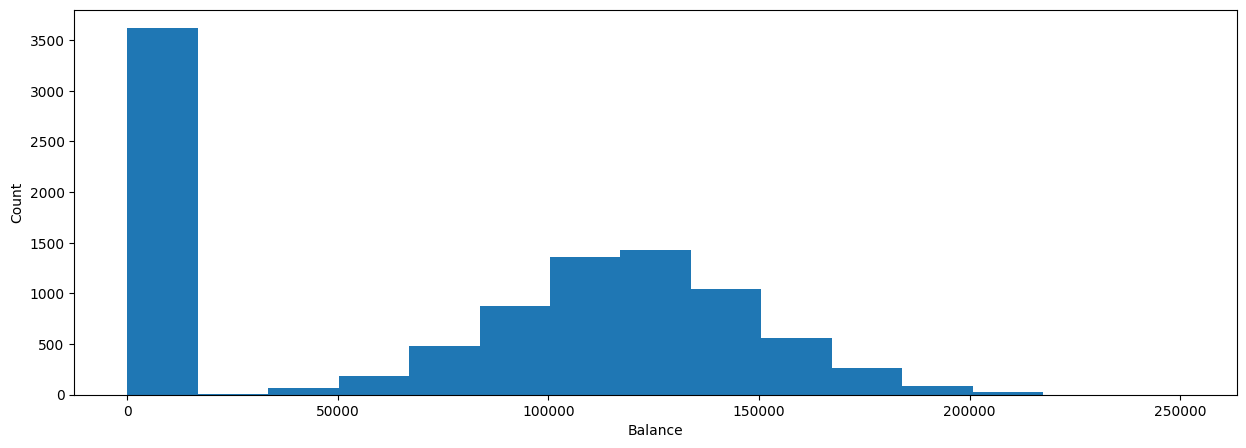

In [25]:
plt.figure(figsize=(15, 5))

plt.hist(
    df["Balance"],
    bins=15
)
plt.xlabel("Balance")
plt.ylabel("Count")

plt.savefig("../outputs/figures/balance_distribution.png", bbox_inches="tight")

Distribución del churn en balance

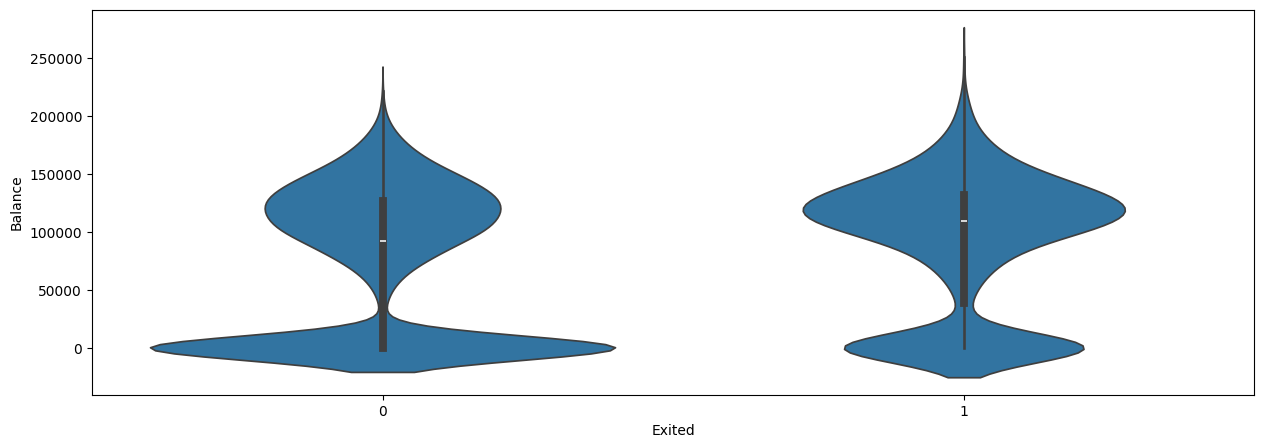

In [26]:
plt.figure(figsize=(15, 5))

sns.violinplot(
    df,
    x="Exited",
    y="Balance"
)

plt.savefig("../outputs/figures/balance_distribution_for_exited.png", bbox_inches="tight")

Crear feature de HasBalance

In [27]:
df["HasBalance"] = (df["Balance"] > 0).astype(int)

In [28]:
print(df[["Balance", "HasBalance"]].head())

     Balance  HasBalance
0       0.00           0
1   83807.86           1
2  159660.80           1
3       0.00           0
4  125510.82           1


Obtener recuento de Exited agrupando por HasBalance

In [29]:
exited_x_hasBalance = df.groupby("HasBalance")["Exited"].value_counts()

In [30]:
exited_x_hasBalance = exited_x_hasBalance.unstack()

In [31]:
print(exited_x_hasBalance)

Exited         0     1
HasBalance            
0           3117   500
1           4846  1537


Ver porcentaje de churn si tiene o no tiene balance

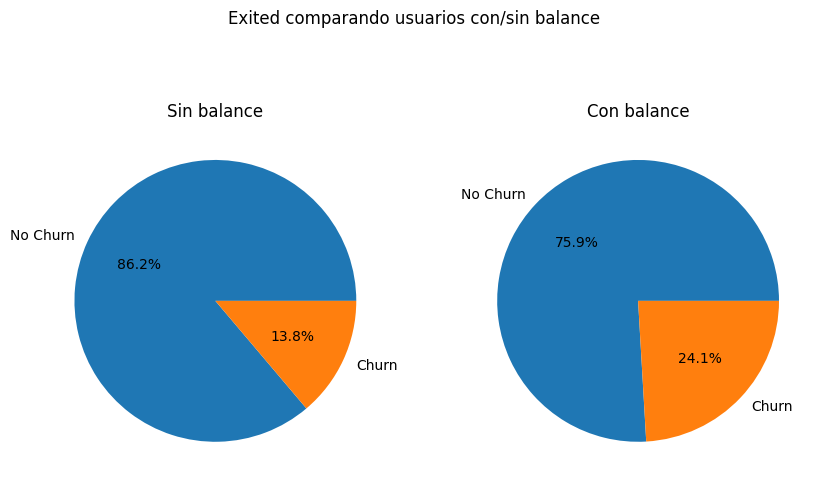

In [32]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 6))

fig.suptitle("Exited comparando usuarios con/sin balance")

axs1 = axs[0]
axs2 = axs[1]

#----------------------------
axs1.pie(
    exited_x_hasBalance.loc[0],
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)
axs1.set_title("Sin balance")
#----------------------------
axs2.pie(
    exited_x_hasBalance.loc[1],
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)
axs2.set_title("Con balance")

plt.savefig("../outputs/figures/exited_by_balance.png", bbox_inches="tight")

#### Churn por NumOfProducts

In [33]:
churn_x_NumOfProducts = df.groupby("NumOfProducts")["Exited"].value_counts()

In [34]:
churn_x_NumOfProducts = churn_x_NumOfProducts.unstack()

In [35]:
print(churn_x_NumOfProducts)

Exited              0       1
NumOfProducts                
1              3675.0  1409.0
2              4242.0   348.0
3                46.0   220.0
4                 NaN    60.0


In [36]:
churn_x_NumOfProducts = churn_x_NumOfProducts.fillna(0)

In [37]:
print(churn_x_NumOfProducts)

Exited              0       1
NumOfProducts                
1              3675.0  1409.0
2              4242.0   348.0
3                46.0   220.0
4                 0.0    60.0


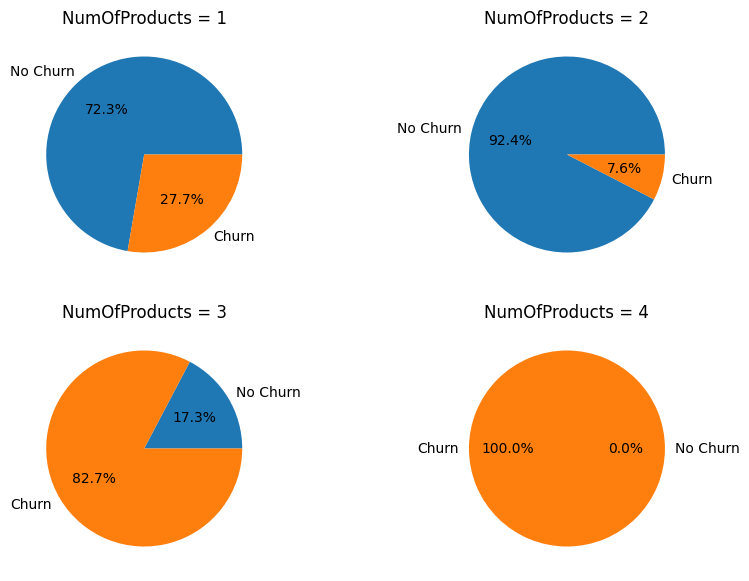

In [38]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 7))

axs1 = axs[0][0]
axs2 = axs[0][1]
axs3 = axs[1][0]
axs4 = axs[1][1]

#------------------
axs1.pie(
    churn_x_NumOfProducts.loc[1],
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)
axs1.set_title("NumOfProducts = 1")
#------------------
axs2.pie(
    churn_x_NumOfProducts.loc[2],
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)
axs2.set_title("NumOfProducts = 2")
#------------------
axs3.pie(
    churn_x_NumOfProducts.loc[3],
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)
axs3.set_title("NumOfProducts = 3")
#------------------
axs4.pie(
    churn_x_NumOfProducts.loc[4],
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)
axs4.set_title("NumOfProducts = 4")
#------------------

plt.savefig("../outputs/figures/churn_by_NumOfProducts.png", bbox_inches="tight")


#### Exited por HasCrCArd

In [39]:
exited_x_HasCrCard = df.groupby("HasCrCard")["Exited"].value_counts()

In [40]:
print(exited_x_HasCrCard)

HasCrCard  Exited
0          0         2332
           1          613
1          0         5631
           1         1424
Name: count, dtype: int64


In [41]:
exited_x_HasCrCard = exited_x_HasCrCard.unstack()

In [42]:
print(exited_x_HasCrCard)

Exited        0     1
HasCrCard            
0          2332   613
1          5631  1424


<Figure size 1500x500 with 0 Axes>

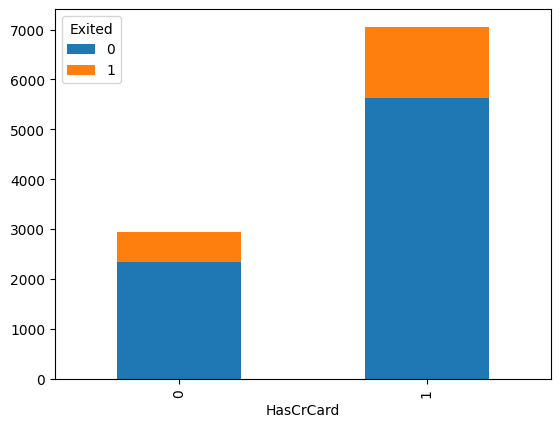

In [43]:
plt.figure(figsize=(15, 5))

exited_x_HasCrCard.plot(
    kind="bar",
    stacked=True
)

plt.savefig("../outputs/figures/exited_by_CrCard_count.png", bbox_inches="tight")

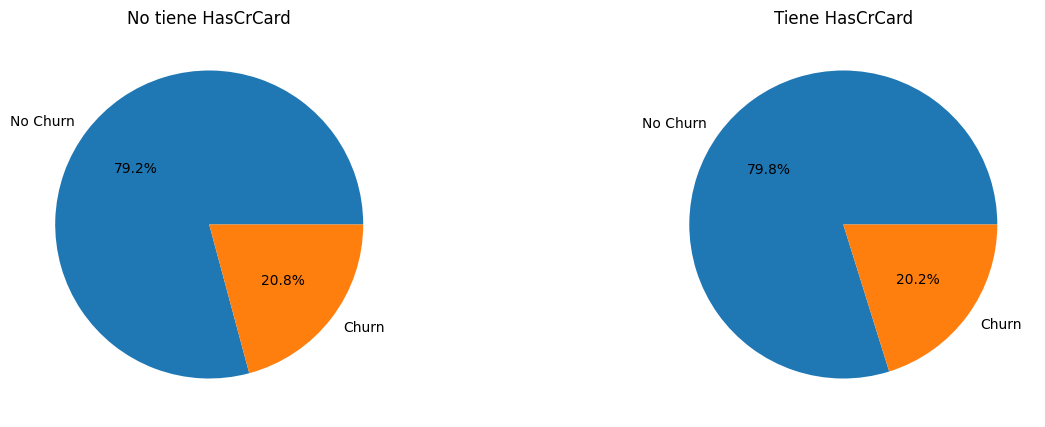

In [44]:
fig, axs = plt.subplots(ncols=2, figsize=(15, 5))

axs1 = axs[0]
axs2 = axs[1]

axs1.pie(
    exited_x_HasCrCard.loc[0],
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)
axs1.set_title("No tiene HasCrCard")

axs2.pie(
    exited_x_HasCrCard.loc[1],
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)
axs2.set_title("Tiene HasCrCard")

plt.savefig("../outputs/figures/exited_by_geography_pie.png", bbox_inches="tight")

#### Exited por IsActiveMember

Aquí aprovecharemos de confirmar teoría en conjunto de HasBalance, veremos si los miembros más activos tienden a irse más

In [45]:
exited_x_IsActiveMember = df.groupby("IsActiveMember")["Exited"].value_counts()

In [46]:
exited_x_IsActiveMember = exited_x_IsActiveMember.unstack()

In [47]:
print(exited_x_IsActiveMember)

Exited             0     1
IsActiveMember            
0               3547  1302
1               4416   735


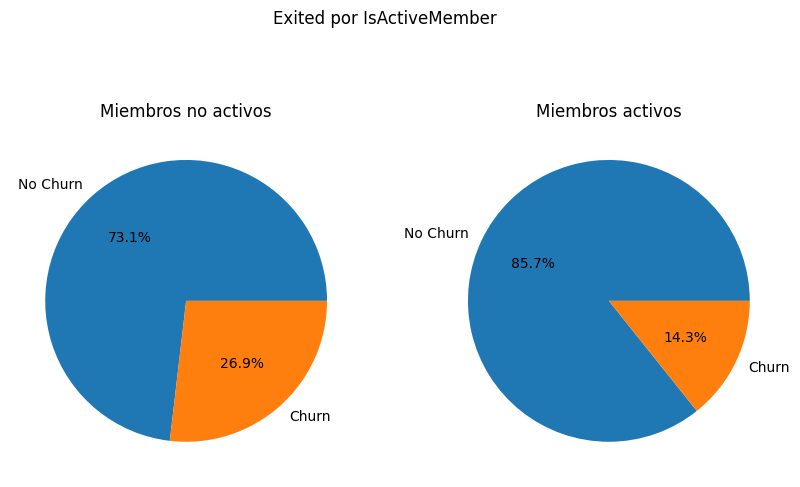

In [48]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 6))

fig.suptitle("Exited por IsActiveMember")

axs1 = axs[0]
axs2 = axs[1]

#------------------------------
axs1.pie(
    exited_x_IsActiveMember.loc[0],
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)


axs1.set_title("Miembros no activos")
#------------------------------
axs2.pie(
    exited_x_IsActiveMember.loc[1],
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)
axs2.set_title("Miembros activos")
#------------------------------

plt.savefig("../outputs/figures/active_members_exited.png", bbox_inches="tight")

#### Distribución por EstimatedSalary

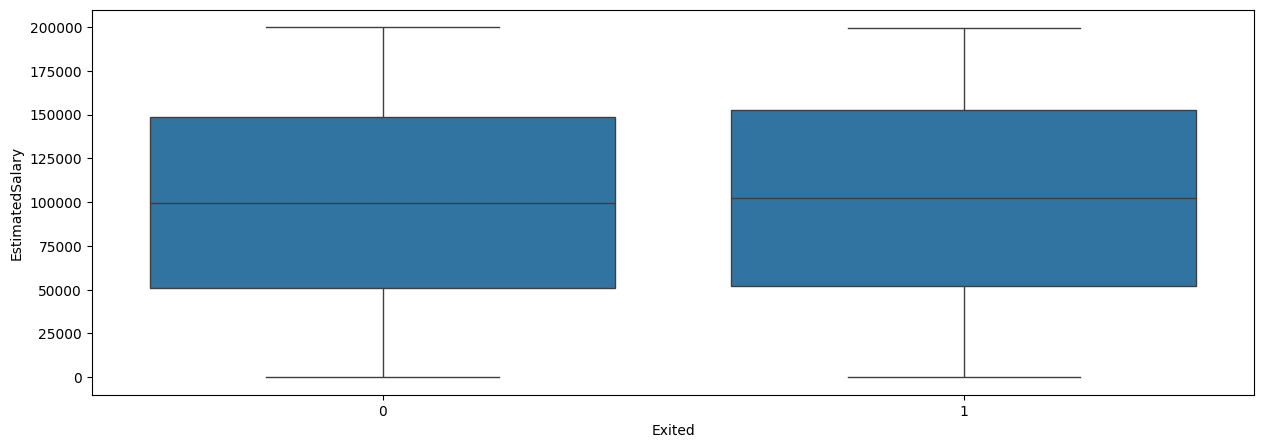

In [49]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    df,
    x="Exited",
    y="EstimatedSalary"
)

plt.savefig("../outputs/figures/exited_by_EstimatedSalary.png", bbox_inches="tight")

#### Dataset final de EDA

In [50]:
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited AgeGroup  HasBalance  
0        101348.88       1    Adult           0  
1        112542.58       0    Adult           1  
2       